In [1]:
"""
Lecture 1.6 Supplemental Code

Jackson School of Global Affairs                 
                                                 
 Created by Ardina Hasanbasri for GLBL 5021      
                                                 
Additional reference code and data used:        
Békés & Kézdi (2021) see more code below         
https://gabors-data-analysis.com/               
                                            
"""

# The main analysis that replicates the code from the slides
# are in Part II. Part I explains how the data was cleaned, 
# but can be skipped. 

#------------------------------------------------#
# Setting Up and Load Data                       #
# -----------------------------------------------#

import os
import sys
import warnings
import numpy as np
import pandas as pd
import pyfixest as pf
import seaborn as sns
import matplotlib.pyplot as plt
import pyreadstat
from statsmodels.nonparametric.smoothers_lowess import lowess
import statsmodels.formula.api as smf
from typing import List
warnings.filterwarnings("ignore") 

share = pd.read_csv("https://osf.io/download/kbjzp/")

In [2]:
#------------------------------------------------#
# Part I Data Cleaning                           #
# -----------------------------------------------#

share["healthy"] = 0
share.loc[(share["sphus"] == 1) | (share["sphus"] == 2), "healthy"] = 1
share.loc[~((share["sphus"] > 0) & (share["sphus"] <= 5)), "healthy"] = np.nan

share["baseline"] = 0
share.loc[share["wave"] == 4, "baseline"] = 1
share["endline"] = 0
share.loc[share["wave"] == 6, "endline"] = 1

share["temp"] = np.where(
    share["endline"] == 1, np.where(share["healthy"] == 1, 1, 0), np.nan
)

share["stayshealthy"] = share.groupby("mergeid")["temp"].transform(np.nanmax)

share = share.drop("temp", axis=1)

# keep if endline health outcome non-missing
share = share.loc[lambda x: (x["stayshealthy"] == 1) | (x["stayshealthy"] == 0)]

# keep baseline observations (endline outcome already defined for them)
share = share.loc[lambda x: x["baseline"] == 1]

# keep age 50-60 at baseline
share = share.loc[lambda x: (x["age"] >= 50) & (x["age"] <= 60)]

# keep healthy individuals at baseline
share = share.loc[lambda x: x["healthy"] == 1]

# keep those with non-missing observations for smoking at baseline
# and re-define smoking to be 0-1
share.loc[lambda x: x["smoking"] == 5, "smoking"] = 0
share = share.loc[lambda x: (x["smoking"] == 0) | (x["smoking"] == 1)]

share.loc[lambda x: x["ever_smoked"] == 5, "ever_smoked"] = 0
share = share.loc[lambda x: (x["ever_smoked"] == 0) | (x["ever_smoked"] == 1)]

share["exerc"] = np.where(
    share["br015"] == 1,
    1,
    np.where((share["br015"] > 0) & (share["br015"] != 1), 0, np.nan),
)

share["bmi"] = np.where(share["bmi"] < 0, np.nan, share["bmi"])

share["bmi"].describe().round(2)

share = share.rename(columns={"income_pct_w4": "income10"})

share["married"] = np.where((share["mar_stat"] == 1) | (share["mar_stat"] == 2), 1, 0)

share["eduyears"] = np.where(share["eduyears_mod"] < 0, np.nan, share["eduyears_mod"])

share["eduyears"].describe().round(2)

share = share.drop("eduyears_mod", axis=1)

share = share.loc[
    lambda x: (x["bmi"].notnull()) & (x["eduyears"].notnull()) & (x["exerc"].notnull())
]

In [5]:
#------------------------------------------------#
# Part II Simple LPM Models                      #
# -----------------------------------------------#

# (1) current smoker on RHS
lpm1 = pf.feols("stayshealthy ~ smoking", data=share,vcov="HC1")

# (2) current smoker and ever smoked on RHS
lpm2 = pf.feols("stayshealthy ~ smoking + ever_smoked", data=share,vcov="HC1")

pf.etable([lpm1, lpm2])

GT(_tbl_data=  level_0             level_1                      0                      1
0    coef             smoking  -0.069** <br> (0.021)  -0.078** <br> (0.025)
1    coef         ever_smoked                            0.014 <br> (0.020)
2    coef           Intercept  0.620*** <br> (0.010)  0.615*** <br> (0.012)
3   stats        Observations                   3112                   3112
4   stats           S.E. type                 hetero                 hetero
5   stats       R<sup>2</sup>                  0.003                  0.004
6   stats  Adj. R<sup>2</sup>                  0.003                  0.003, _body=<great_tables._gt_data.Body object at 0x000001CE008ECA10>, _boxhead=Boxhead([ColInfo(var='level_0', type=<ColInfoTypeEnum.row_group: 3>, column_label='level_0', column_align='center', column_width=None), ColInfo(var='level_1', type=<ColInfoTypeEnum.stub: 2>, column_label='level_1', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label='(2)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000001CE008EC410>, _spanners=Spanners([SpannerInfo(spanner_id='stayshealthy', spanner_level=1, spanner_label='stayshealthy', spanner_units=None, spanner_pattern=None, vars=['0', '1'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000001CE008ECF50>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000001CE008ECF20>, _source_notes=['Significance levels: * p < 0.05, ** p < 0.01, *** p < 0.001. Format of coefficient cell:\nCoefficient \n (Std. Error)'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000001CE008ECE00>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border

In [13]:
# compare these means with the coefficients above of interests
a = share["stayshealthy"][share["smoking"] == 0].mean()
b = share["stayshealthy"][share["smoking"] == 1].mean()
b-a

c = share.loc[
    (share["smoking"] == 0) & (share["ever_smoked"] == 0),
    "stayshealthy"
].mean()

d = share.loc[
    (share["smoking"] == 0) & (share["ever_smoked"] == 1),
    "stayshealthy"
].mean()

d-c

np.float64(0.01444168426189485)

In [34]:
# Create splines 
x = share["eduyears"].to_numpy()

share["edu_years1"] = np.minimum(x, 8.0)
share["edu_years2"] = np.minimum(np.maximum(x - 8.0, 0.0), 18.0 - 8.0)  
share["edu_years3"] = np.maximum(x - 18.0, 0.0)

x = share["bmi"].to_numpy()
share["bmi1"] = np.minimum(x, 35)
share["bmi2"] = np.minimum(np.maximum(x - 35.0, 0.0), 35.0) 


In [37]:
# Check splines 
check_df1 = pd.DataFrame(np.column_stack([share["eduyears"], share["edu_years1"], share["edu_years2"], share["edu_years3"]]))
check_df2 = pd.DataFrame(np.column_stack([share["bmi"], share["bmi1"], share["bmi2"]]))

check_df1

,0,1,2,3
0,13.0,8.0,5.0,0.0
1,14.0,8.0,6.0,0.0
2,23.0,8.0,10.0,5.0
3,12.0,8.0,4.0,0.0
4,3.0,3.0,0.0,0.0
...,...,...,...,...
3107,16.0,8.0,8.0,0.0
3108,17.0,8.0,9.0,0.0
3109,11.0,8.0,3.0,0.0
3110,4.0,4.0,0.0,0.0


In [39]:

# (3) rich lpm
lpm3 = pf.feols("stayshealthy ~ smoking + ever_smoked + female + age + edu_years1 + edu_years2 + edu_years3 + income10 + bmi1 +bmi2 + exerc + country",
    share,
    vcov="HC1",
    context=0)

pf.etable([lpm3])


GT(_tbl_data=   level_0             level_1                       0
0     coef             smoking   -0.067** <br> (0.024)
1     coef         ever_smoked      0.021 <br> (0.020)
2     coef              female      0.027 <br> (0.018)
3     coef                 age     -0.003 <br> (0.003)
4     coef          edu_years1    -0.018* <br> (0.007)
5     coef          edu_years2   0.023*** <br> (0.003)
6     coef          edu_years3     -0.016 <br> (0.012)
7     coef            income10    0.008** <br> (0.003)
8     coef                bmi1  -0.013*** <br> (0.003)
9     coef                bmi2      0.008 <br> (0.018)
10    coef               exerc   0.063*** <br> (0.017)
11    coef             country  -0.009*** <br> (0.001)
12    coef           Intercept   1.223*** <br> (0.187)
13   stats        Observations                    3112
14   stats           S.E. type                  hetero
15   stats       R<sup>2</sup>                   0.061
16   stats  Adj. R<sup>2</sup>                   0.058, _body=<great_tables._gt_data.Body object at 0x000001CE007787A0>, _boxhead=Boxhead([ColInfo(var='level_0', type=<ColInfoTypeEnum.row_group: 3>, column_label='level_0', column_align='center', column_width=None), ColInfo(var='level_1', type=<ColInfoTypeEnum.stub: 2>, column_label='level_1', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000001CE00779BB0>, _spanners=Spanners([SpannerInfo(spanner_id='stayshealthy', spanner_level=1, spanner_label='stayshealthy', spanner_units=None, spanner_pattern=None, vars=['0'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000001CE0077A450>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000001CE0077B9B0>, _source_notes=['Significance levels: * p < 0.05, ** p < 0.01, *** p < 0.001. Format of coefficient cell:\nCoefficient \n (Std. Error)'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000001CE00779AC0>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsIn

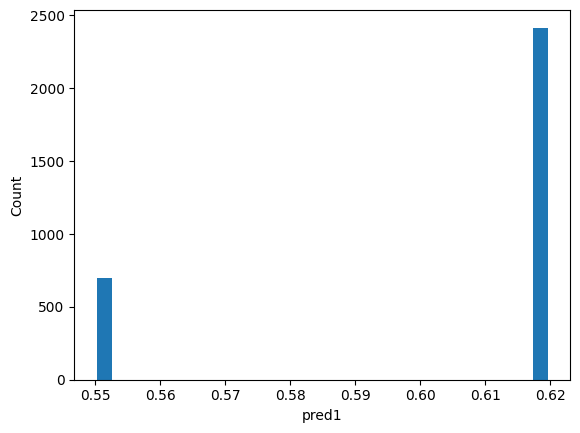

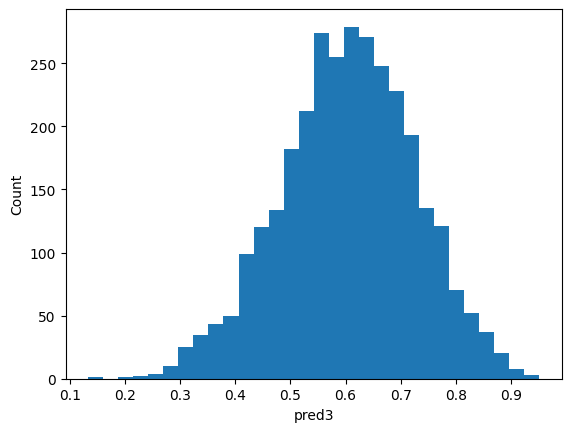

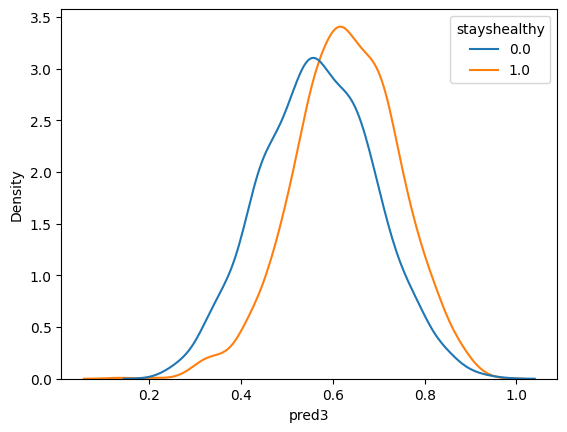

In [40]:
# Get predictions
share["pred1"] = lpm1.predict(share)
share["pred3"] = lpm3.predict(share)

plt.hist(share["pred1"], bins=30)
plt.xlabel("pred1")
plt.ylabel("Count")
plt.show()

plt.hist(share["pred3"], bins=30)
plt.xlabel("pred3")
plt.ylabel("Count")
plt.show()

sns.kdeplot(
    data=share,
    x="pred3",
    hue="stayshealthy",
    common_norm=False
)
plt.show()

